## Setup

In [1]:
import sys
import os

# Add project root to path so src/ imports work from the notebooks/ folder
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

In [2]:
from src.tabular.clean import load_listings, clean_price_column

## Part 1 — Raw data exploration (all listings)

Distributions, missing values, and relationships across the full raw dataset (6,996 rows).
The goal is to understand the data and justify pipeline decisions.
Nothing computed here feeds into the model.

In [3]:
df = load_listings("../data/raw/listings.csv")
print(df.shape)

(6996, 79)


In [4]:
print(df.columns.tolist())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [5]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6606,https://www.airbnb.com/rooms/6606,20250925032813,2025-09-25,city scrape,"Fab, private seattle urban cottage!","This tiny cottage is only 15x10, but it has ev...","A peaceful yet highly accessible neighborhood,...",https://a0.muscache.com/pictures/45742/21116d7...,14942,...,4.77,4.88,4.57,str-opli-19-002622,f,3,3,0,0,0.82
1,9419,https://www.airbnb.com/rooms/9419,20250925032813,2025-09-25,city scrape,Glorious sun room w/ memory foambed,This beautiful double room features sun filled...,"Lots of restaurants (see our guide book) bars,...",https://a0.muscache.com/pictures/56645186/e5fb...,30559,...,4.89,4.70,4.69,Exempt,f,10,0,10,0,1.19
2,9596,https://www.airbnb.com/rooms/9596,20250925032813,2025-09-25,previous scrape,"the down home , spacious, central and fab!","We are in a great neighborhood, quiet, full of...","if you arrive early for check in at 3, I reco...",https://a0.muscache.com/pictures/665252/102d18...,14942,...,4.66,4.91,4.56,STR -OPLI-19-002622,f,3,3,0,0,0.56
3,11012,https://www.airbnb.com/rooms/11012,20250925032813,2025-09-25,city scrape,"the orange house, quiet 'n central",NaN,NaN,https://a0.muscache.com/pictures/682034/54bc27...,14942,...,4.72,4.86,4.74,str-opli-19-002622,f,3,3,0,0,0.51
4,25002,https://www.airbnb.com/rooms/25002,20250925032813,2025-09-25,city scrape,Beautiful Private Spot in North Ballard,"-Great eating , Delancey, Fat Hen, 3 blocks aw...",Great walking neighborhood! We are in between...,https://a0.muscache.com/pictures/491561/cf5270...,102684,...,4.98,4.90,4.90,STR-OPLI-19-002617,t,1,1,0,0,6.06


## Missing values and dtypes

In [6]:
print(df.dtypes)

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object


In [7]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"{len(missing_pct)} columns have missing values")
missing_pct

42 columns have missing values


calendar_updated               100.000000
neighbourhood                   40.308748
neighborhood_overview           40.308748
host_about                      34.748428
host_location                   20.325901
license                         17.309891
host_response_rate              15.280160
host_response_time              15.280160
first_review                    12.678674
last_review                     12.678674
review_scores_rating            12.678674
review_scores_accuracy          12.678674
review_scores_cleanliness       12.678674
review_scores_checkin           12.678674
review_scores_communication     12.678674
review_scores_location          12.678674
reviews_per_month               12.678674
review_scores_value             12.678674
host_acceptance_rate            12.635792
estimated_revenue_l365d         11.077759
price                           11.077759
beds                            10.162950
bathrooms                       10.120069
host_neighbourhood               9

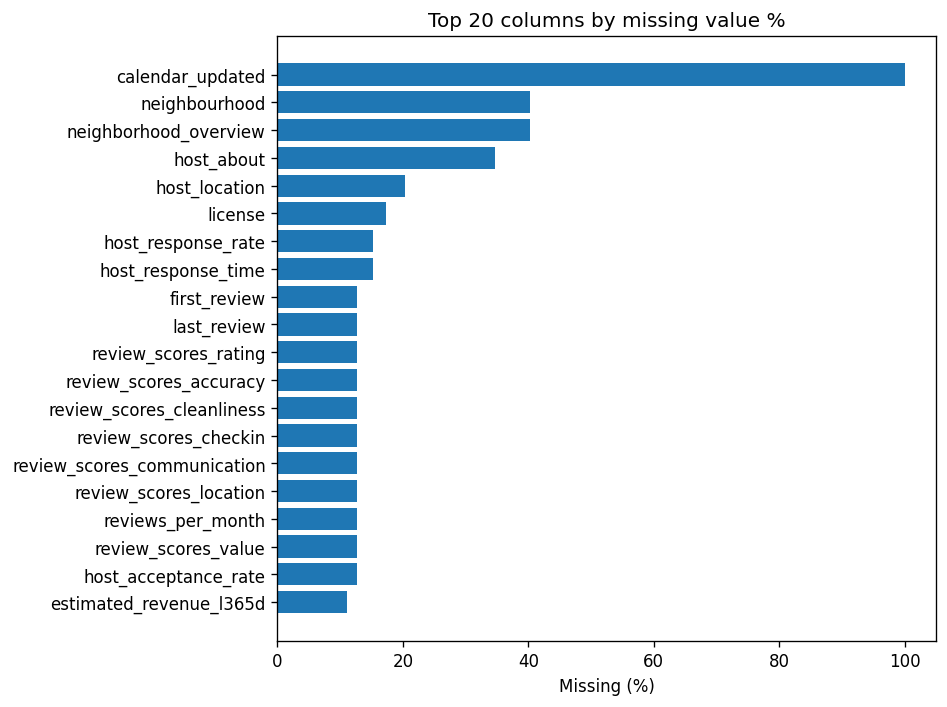

In [8]:
top20 = missing_pct.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1])
ax.set_xlabel("Missing (%)")
ax.set_title("Top 20 columns by missing value %")
plt.tight_layout()
plt.show()

## Price column — before and after cleaning

In [9]:
print("dtype before cleaning:", df["price"].dtype)
df["price"].head(10)

dtype before cleaning: str


0     $99.00
1     $71.00
2        NaN
3    $311.00
4     $88.00
5    $154.00
6     $92.00
7    $275.00
8     $53.00
9    $111.00
Name: price, dtype: str

In [10]:
df = clean_price_column(df)
df["price"].describe()

count     6221.000000
mean       571.716123
std       4137.408761
min         15.000000
25%        105.000000
50%        149.000000
75%        212.000000
max      50039.000000
Name: price, dtype: float64

In [11]:
price_sorted = df["price"].dropna().sort_values()
print("10 lowest prices:")
print(price_sorted.head(10).values)
print()
print("10 highest prices:")
print(price_sorted.tail(10).values)

10 lowest prices:
[15. 16. 16. 17. 18. 20. 21. 21. 21. 22.]

10 highest prices:
[50000. 50000. 50000. 50000. 50000. 50037. 50037. 50037. 50039. 50039.]


In [12]:
price_clean = df["price"].dropna()
print(f"Prices < $10  (likely errors):   {(price_clean < 10).sum()}")
print(f"Prices > $1,000 (luxury/outlier): {(price_clean > 1000).sum()}")
print(f"Prices > $5,000 (extreme outlier): {(price_clean > 5000).sum()}")

Prices < $10  (likely errors):   0
Prices > $1,000 (luxury/outlier): 85
Prices > $5,000 (extreme outlier): 58


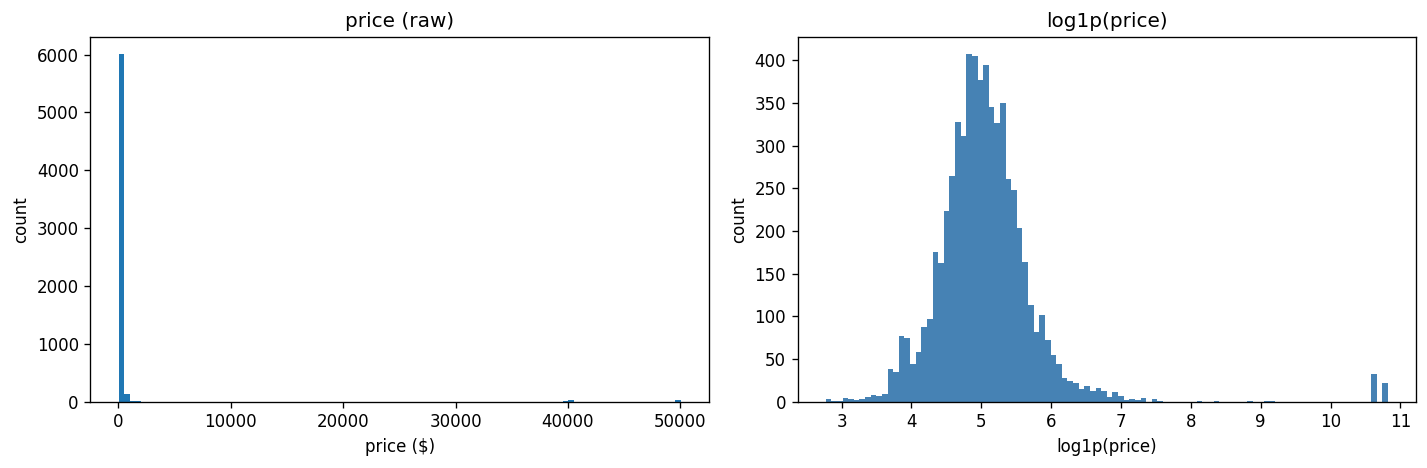

In [13]:
price_clean = df["price"].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(price_clean, bins=100, edgecolor="none")
ax1.set_title("price (raw)")
ax1.set_xlabel("price ($)")
ax1.set_ylabel("count")

ax2.hist(np.log1p(price_clean), bins=100, edgecolor="none", color="steelblue")
ax2.set_title("log1p(price)")
ax2.set_xlabel("log1p(price)")
ax2.set_ylabel("count")

plt.tight_layout()
plt.show()

## Key feature columns — first look

In [14]:
EXPECTED_COLS = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "host_is_superhost",
]

present = [c for c in EXPECTED_COLS if c in df.columns]
missing = [c for c in EXPECTED_COLS if c not in df.columns]

print("Present:", present)
print("Missing:", missing)

Present: ['accommodates', 'bedrooms', 'bathrooms', 'room_type', 'property_type', 'neighbourhood_cleansed', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'host_is_superhost']
Missing: []


In [15]:
NUMERIC_COLS = [
    "accommodates", "bedrooms", "bathrooms",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "review_scores_rating",
]

numeric_present = [c for c in NUMERIC_COLS if c in df.columns]
df[numeric_present].describe()

,accommodates,bedrooms,bathrooms,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating
count,6996.000000,6845.000000,6288.000000,6996.000000,6996.000000,6996.000000,6109.000000
mean,4.010292,1.661066,1.456266,10.990709,389.699257,82.307604,4.808836
std,2.595572,1.182109,0.834621,18.718235,429.112014,126.641425,0.338030
min,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,30.000000,5.000000,4.780000
50%,4.000000,1.000000,1.000000,2.000000,365.000000,32.000000,4.900000
75%,5.000000,2.000000,2.000000,30.000000,365.000000,105.000000,4.980000
max,16.000000,13.000000,16.000000,365.000000,10000.000000,1577.000000,5.000000


In [16]:
CATEGORICAL_COLS = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_is_superhost",
]

for col in CATEGORICAL_COLS:
    if col not in df.columns:
        print(f"  {col}: not found, skipping")
        continue
    vc = df[col].value_counts().head(15)
    print(f"\n--- {col} (top {len(vc)}) ---")
    print(vc.to_string())


--- room_type (top 4) ---
room_type
Entire home/apt    5745
Private room       1175
Hotel room           51
Shared room          25

--- property_type (top 15) ---
property_type
Entire home                          1857
Entire rental unit                   1667
Private room in home                  692
Entire townhouse                      566
Entire condo                          538
Entire guest suite                    537
Entire guesthouse                     310
Private room in rental unit           122
Room in hotel                         116
Private room in townhouse              91
Room in boutique hotel                 90
Entire serviced apartment              65
Entire loft                            55
Entire cottage                         48
Private room in bed and breakfast      31

--- neighbourhood_cleansed (top 15) ---
neighbourhood_cleansed
Belltown                     380
Broadway                     375
University District          287
Wallingford                 

## Price vs features

In [17]:
if "room_type" in df.columns:
    grp = (
        df.groupby("room_type")["price"]
        .agg(mean="mean", median="median")
        .sort_values("mean", ascending=False)
    )
    print(grp.round(2).to_string())
else:
    print("room_type not found in dataframe")

                     mean   median
room_type                         
Hotel room       43989.88  40100.0
Entire home/apt    260.42    161.0
Private room       102.67     76.0
Shared room         31.12     22.5


In [18]:
if "neighbourhood_cleansed" in df.columns:
    grp = (
        df.groupby("neighbourhood_cleansed")["price"]
        .agg(count="count", mean="mean", median="median")
        .sort_values("mean", ascending=False)
        .head(15)
    )
    print(grp.round(2).to_string())
else:
    print("neighbourhood_cleansed not found in dataframe")

                           count      mean  median
neighbourhood_cleansed                            
Central Business District    115  11748.59   250.0
Pike-Market                   94   6063.14   236.0
Belltown                     339   1811.17   176.0
Industrial District            1    664.00   664.0
Laurelhurst                   25    310.28   169.0
Phinney Ridge                 87    305.64   175.0
Lower Queen Anne             107    265.79   210.0
South Lake Union              88    262.43   227.5
Madison Park                  19    253.79   233.0
East Queen Anne              140    246.09   181.0
Madrona                       39    240.64   188.0
Southeast Magnolia            28    232.93   167.0
Eastlake                     137    230.42   132.0
Windermere                    15    227.27   180.0
Harrison/Denny-Blaine         24    226.08   168.5


### neighbourhood_group_cleansed — coarser alternative

In [19]:
if "neighbourhood_group_cleansed" in df.columns:
    print(f"Unique districts: {df['neighbourhood_group_cleansed'].nunique()}")
    print()
    print("Listing counts per district:")
    print(df["neighbourhood_group_cleansed"].value_counts().to_string())
    print()
    grp = (
        df.groupby("neighbourhood_group_cleansed")["price"]
        .agg(count="count", mean="mean", median="median")
        .sort_values("mean", ascending=False)
    )
    print("Mean/median price per district:")
    print(grp.round(1).to_string())
else:
    print("neighbourhood_group_cleansed: column not found")

Unique districts: 17

Listing counts per district:
neighbourhood_group_cleansed
Other neighborhoods    1371
Downtown                899
Central Area            637
Capitol Hill            585
Queen Anne              576
West Seattle            503
Ballard                 417
Rainier Valley          381
Cascade                 289
University District     287
Beacon Hill             285
Northgate               238
Delridge                218
Lake City               123
Magnolia                111
Seward Park              59
Interbay                 17

Mean/median price per district:
                              count    mean  median
neighbourhood_group_cleansed                       
Downtown                        798  3227.7   177.0
Cascade                         245   236.9   182.0
Queen Anne                      513   226.7   178.0
Magnolia                        102   192.4   152.5
Other neighborhoods            1221   187.5   135.0
Capitol Hill                    549   183.7   1

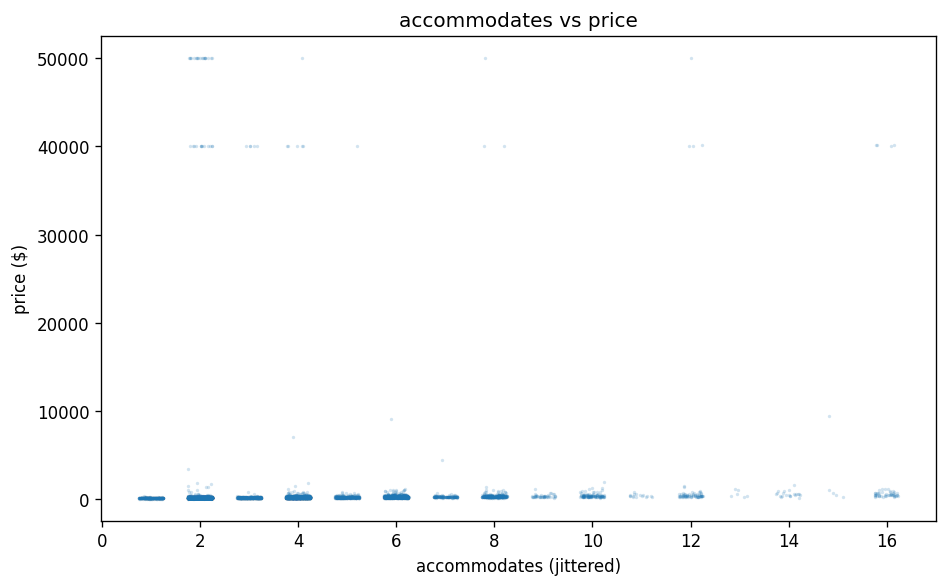

In [20]:
if "accommodates" in df.columns:
    plot_df = df[["accommodates", "price"]].dropna()
    rng = np.random.default_rng(0)
    jitter = rng.uniform(-0.25, 0.25, size=len(plot_df))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        plot_df["accommodates"] + jitter,
        plot_df["price"],
        s=4, alpha=0.2, linewidths=0,
    )
    ax.set_xlabel("accommodates (jittered)")
    ax.set_ylabel("price ($)")
    ax.set_title("accommodates vs price")
    plt.tight_layout()
    plt.show()
else:
    print("accommodates not found in dataframe")

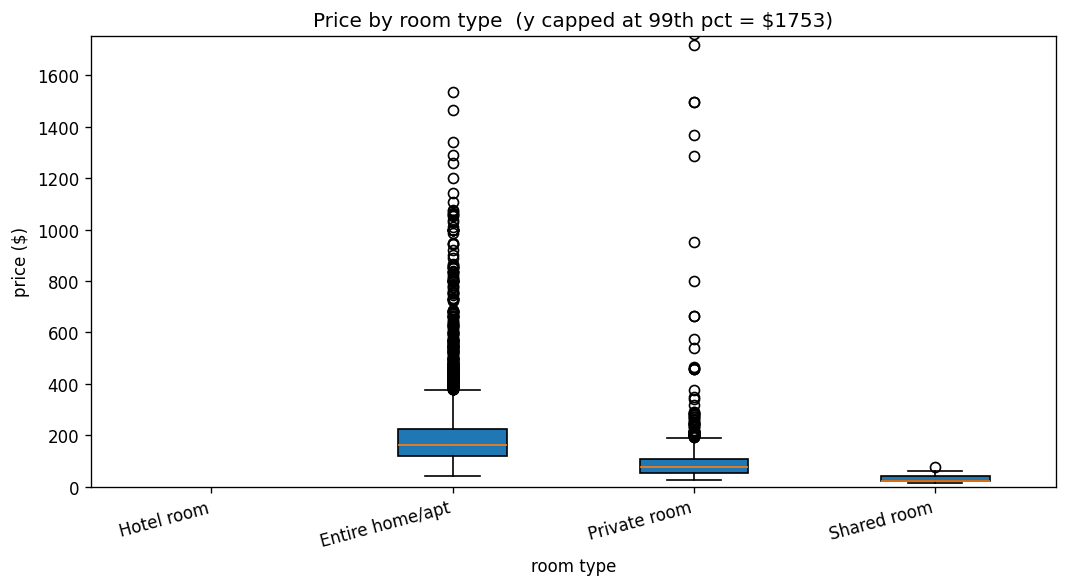

In [21]:
if "room_type" in df.columns:
    cap = df["price"].quantile(0.99)
    room_types = (
        df.groupby("room_type")["price"]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )
    data_by_room = [
        df.loc[df["room_type"] == rt, "price"].dropna().values
        for rt in room_types
    ]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(data_by_room, tick_labels=room_types, patch_artist=True)
    ax.set_ylim(0, cap)
    ax.set_xlabel("room type")
    ax.set_ylabel("price ($)")
    ax.set_title(
        f"Price by room type  (y capped at 99th pct = ${cap:.0f})"
    )
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("room_type not found in dataframe")

## Correlation matrix — numeric features

In [22]:
NUMERIC_CANDIDATES = [
    "accommodates", "bedrooms", "bathrooms", "beds",
    "minimum_nights", "maximum_nights",
    "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
    "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    "number_of_reviews", "number_of_reviews_ltm", "number_of_reviews_l30d",
    "review_scores_rating",
    "availability_30", "availability_60", "availability_90", "availability_365",
    "calculated_host_listings_count",
    "price",
]

corr_cols = [c for c in NUMERIC_CANDIDATES if c in df.columns]
dropped   = [c for c in NUMERIC_CANDIDATES if c not in df.columns]

print(f"Using {len(corr_cols)} columns for correlation analysis.")
if dropped:
    print(f"Dropped (not in dataframe): {dropped}")

Using 22 columns for correlation analysis.


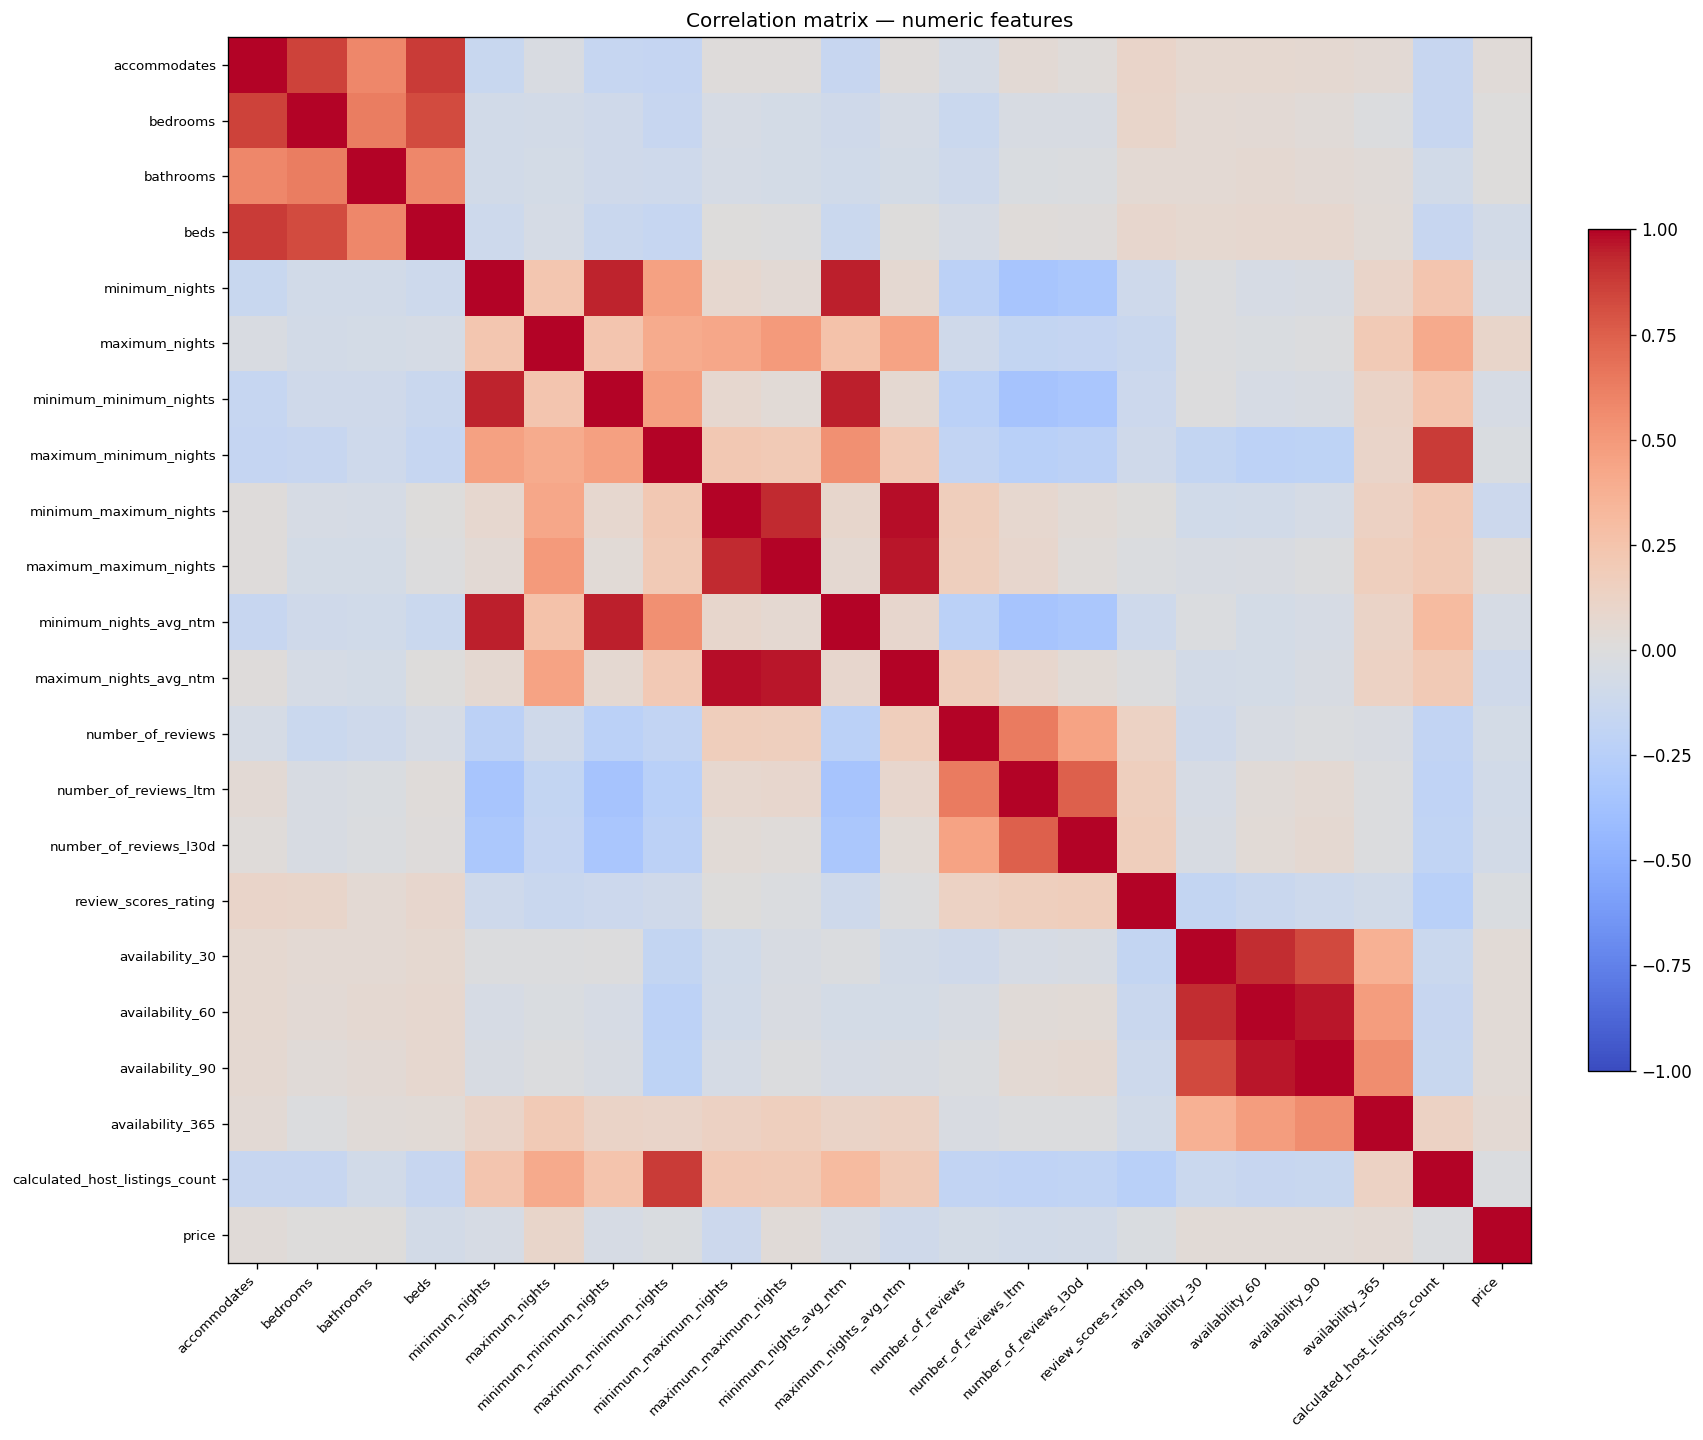

In [23]:
corr = df[corr_cols].corr()
n = len(corr_cols)

fig, ax = plt.subplots(figsize=(max(8, n * 0.65), max(7, n * 0.55)))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)
ax.set_title("Correlation matrix — numeric features")

# Annotate cells only when the matrix is small enough to be readable
if n <= 15:
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{corr.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=6,
                    color="black" if abs(corr.values[i, j]) < 0.7 else "white")

plt.tight_layout()
plt.show()

In [24]:
pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if "price" in (c1, c2):
            continue
        val = corr.loc[c1, c2]
        if abs(val) > 0.8:
            pairs.append((c1, c2, val))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)

if pairs:
    print(f"{"col1":<38} {"col2":<38} {"corr":>6}")
    print("-" * 84)
    for c1, c2, v in pairs:
        print(f"{c1:<38} {c2:<38} {v:>6.3f}")
else:
    print("No feature pairs with |correlation| > 0.8 found.")

col1                                   col2                                     corr
------------------------------------------------------------------------------------
minimum_maximum_nights                 maximum_nights_avg_ntm                  0.979
maximum_maximum_nights                 maximum_nights_avg_ntm                  0.966
availability_60                        availability_90                         0.964
minimum_minimum_nights                 minimum_nights_avg_ntm                  0.952
minimum_nights                         minimum_nights_avg_ntm                  0.952
minimum_nights                         minimum_minimum_nights                  0.944
minimum_maximum_nights                 maximum_maximum_nights                  0.925
availability_30                        availability_60                         0.915
accommodates                           beds                                    0.880
maximum_minimum_nights                 calculated_host_listings_c

## Spot-checking individual columns

### Amenities

In [25]:
if "amenities" in df.columns:
    print("row 0:", df["amenities"].iloc[0])
    print()
    print("row 1:", df["amenities"].iloc[1])
else:
    print("amenities: column not found")

row 0: ["Free parking on premises", "Dedicated workspace", "Self check-in", "Dishes and silverware", "TV", "Kitchen", "Wifi", "Private entrance", "Hangers", "Patio or balcony", "Iron", "Carbon monoxide alarm", "Air conditioning", "Shampoo", "Keypad", "Hair dryer", "Hot water", "Coffee maker", "Smoke alarm", "Bed linens", "Pets allowed", "Fire extinguisher", "Microwave", "Cooking basics", "Refrigerator", "Backyard", "Heating", "Essentials", "Extra pillows and blankets"]

row 1: ["Baking sheet", "Luggage dropoff allowed", "Clothing storage: wardrobe", "Dedicated workspace", "Freezer", "Organic  body soap", "Dishes and silverware", "Central heating", "Mini fridge", "Room-darkening shades", "Bathtub", "Electric stove", "Outdoor dining area", "Kitchen", "Wifi", "Hangers", "Cleaning products", "Iron", "Dining table", "Long term stays allowed", "Lock on bedroom door", "Cleaning available during stay", "Books and reading material", "Shower gel", "Exterior security cameras on property", "Shampo

In [26]:
import ast

def parse_amenities(val):
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except Exception:
        return []

if "amenities" in df.columns:
    _amenities_list = df["amenities"].apply(parse_amenities)
    print("row 0:", _amenities_list.iloc[0])
    print("row 1:", _amenities_list.iloc[1])
else:
    print("amenities: column not found")
    _amenities_list = None

row 0: ['Free parking on premises', 'Dedicated workspace', 'Self check-in', 'Dishes and silverware', 'TV', 'Kitchen', 'Wifi', 'Private entrance', 'Hangers', 'Patio or balcony', 'Iron', 'Carbon monoxide alarm', 'Air conditioning', 'Shampoo', 'Keypad', 'Hair dryer', 'Hot water', 'Coffee maker', 'Smoke alarm', 'Bed linens', 'Pets allowed', 'Fire extinguisher', 'Microwave', 'Cooking basics', 'Refrigerator', 'Backyard', 'Heating', 'Essentials', 'Extra pillows and blankets']
row 1: ['Baking sheet', 'Luggage dropoff allowed', 'Clothing storage: wardrobe', 'Dedicated workspace', 'Freezer', 'Organic  body soap', 'Dishes and silverware', 'Central heating', 'Mini fridge', 'Room-darkening shades', 'Bathtub', 'Electric stove', 'Outdoor dining area', 'Kitchen', 'Wifi', 'Hangers', 'Cleaning products', 'Iron', 'Dining table', 'Long term stays allowed', 'Lock on bedroom door', 'Cleaning available during stay', 'Books and reading material', 'Shower gel', 'Exterior security cameras on property', 'Shampoo

In [27]:
if _amenities_list is not None:
    amenity_counts = _amenities_list.apply(len)
    print(amenity_counts.describe())
else:
    print("amenities: skipping — column not found")

count    6996.000000
mean       43.242853
std        14.539903
min         1.000000
25%        33.000000
50%        44.000000
75%        54.000000
max        92.000000
Name: amenities, dtype: float64


In [28]:
from collections import Counter

if _amenities_list is not None:
    all_amenities = [item for sublist in _amenities_list for item in sublist]
    counter = Counter(all_amenities)
    print(f"Unique amenities: {len(counter)}")
    print()
    print("Top 20 most common amenities:")
    for amenity, count in counter.most_common(20):
        print(f"  {count:>6}  {amenity}")
else:
    print("amenities: skipping — column not found")

Unique amenities: 3562

Top 20 most common amenities:
    6914  Smoke alarm
    6611  Carbon monoxide alarm
    6422  Hot water
    6229  Kitchen
    6159  Hangers
    6124  Hair dryer
    6033  Microwave
    5997  Bed linens
    5952  Wifi
    5922  Essentials
    5769  Dishes and silverware
    5739  Cooking basics
    5723  Shampoo
    5670  Self check-in
    5530  Refrigerator
    5521  Iron
    5314  Fire extinguisher
    4586  Dedicated workspace
    4539  Dishwasher
    4515  First aid kit


### bathrooms vs bathrooms_text

In [29]:
if "bathrooms" in df.columns and "bathrooms_text" in df.columns:
    print(df[["bathrooms", "bathrooms_text"]].sample(15, random_state=1).to_string())
elif "bathrooms" not in df.columns:
    print("bathrooms: column not found")
else:
    print("bathrooms_text: column not found")

      bathrooms  bathrooms_text
4924        2.0         2 baths
4805        NaN         2 baths
3227        1.0          1 bath
2403        1.0          1 bath
994         1.0          1 bath
3397        1.0   1 shared bath
3068        1.0          1 bath
2379        1.0          1 bath
2000        2.0         2 baths
1227        1.0  1 private bath
6129        3.5       3.5 baths
6945        1.0          1 bath
6474        2.0         2 baths
2735        1.0          1 bath
1332        1.0          1 bath


In [30]:
if "bathrooms" in df.columns and "bathrooms_text" in df.columns:
    numeric_missing = df["bathrooms"].isna()
    text_filled     = df["bathrooms_text"].notna() & (df["bathrooms_text"].str.strip() != "")
    recovered = (numeric_missing & text_filled).sum()
    total_missing = numeric_missing.sum()
    print(f"Rows where bathrooms (numeric) is missing:          {total_missing}")
    print(f"Of those, bathrooms_text is filled:                 {recovered}")
    print(f"Rows missing both:                                  {total_missing - recovered}")
else:
    print("skipping — need both bathrooms and bathrooms_text")

Rows where bathrooms (numeric) is missing:          708
Of those, bathrooms_text is filled:                 708
Rows missing both:                                  0


### Date columns

In [31]:
DATE_COLS = ["host_since", "first_review", "last_review", "last_scraped"]

for col in DATE_COLS:
    if col not in df.columns:
        print(f"{col}: not found\n")
        continue
    print(f"--- {col} ---")
    print(f"  dtype: {df[col].dtype}")
    print(f"  first 5 values: {df[col].head().tolist()}")
    print()

--- host_since ---
  dtype: str
  first 5 values: ['2009-04-26', '2009-08-09', '2009-04-26', '2009-04-26', '2010-04-02']

--- first_review ---
  dtype: str
  first 5 values: ['2009-07-17', '2010-07-30', '2011-06-15', '2010-01-31', '2010-04-23']

--- last_review ---
  dtype: str
  first 5 values: ['2024-09-07', '2025-08-31', '2025-07-31', '2021-03-22', '2025-09-16']

--- last_scraped ---
  dtype: str
  first 5 values: ['2025-09-25', '2025-09-25', '2025-09-25', '2025-09-25', '2025-09-25']



In [32]:
if "host_since" in df.columns:
    host_since_dt = pd.to_datetime(df["host_since"], errors="coerce")
    n_nat = host_since_dt.isna().sum()
    n_ok  = host_since_dt.notna().sum()
    print(f"host_since — parsed OK: {n_ok}, failed (NaT): {n_nat}")
    if n_ok > 0:
        print()
        print(host_since_dt.describe())
else:
    print("host_since: column not found")

host_since — parsed OK: 6645, failed (NaT): 351

count                          6645
mean     2017-04-24 21:13:47.268623
min             2008-08-26 00:00:00
25%             2014-08-09 00:00:00
50%             2016-06-24 00:00:00
75%             2020-03-07 00:00:00
max             2025-09-12 00:00:00
Name: host_since, dtype: object


### license

In [33]:
if "license" in df.columns:
    vc = df["license"].dropna().value_counts().head(15)
    print(f"Non-null values: {df['license'].notna().sum()} / {len(df)}")
    print()
    print(vc.to_string())
else:
    print("license: column not found")

Non-null values: 5785 / 6996

license
Exempt                334
STR-OPLI-24-000011     66
STR-OPLI-19-002641     37
str-opli-24-001459     35
STR-OPLI-19-002570     30
STR-OPLI-20-000157     25
STR-OPLI-25-003052     21
STR-OPLI-19-003321     17
STR-OPLI-19-003295     17
STR-OPLI-23-001523     17
STR-OPLI-24-001459     16
STR-OPLI-19-003006     15
STR-OPLI-24-000042     15
STR-OPLI-22-000983     14
STR-OPLI-22-000731     14


### host_response_time and host_response_rate

In [34]:
if "host_response_time" in df.columns:
    print(df["host_response_time"].value_counts(dropna=False).to_string())
else:
    print("host_response_time: column not found")

host_response_time
within an hour        5206
NaN                   1069
within a few hours     429
within a day           215
a few days or more      77


In [35]:
if "host_response_rate" in df.columns:
    print("dtype:", df["host_response_rate"].dtype)
    print()
    print(df["host_response_rate"].head(10).to_string())
else:
    print("host_response_rate: column not found")

dtype: str

0    100%
1    100%
2    100%
3    100%
4    100%
5    100%
6    100%
7    100%
8    100%
9    100%


## Geographic distribution

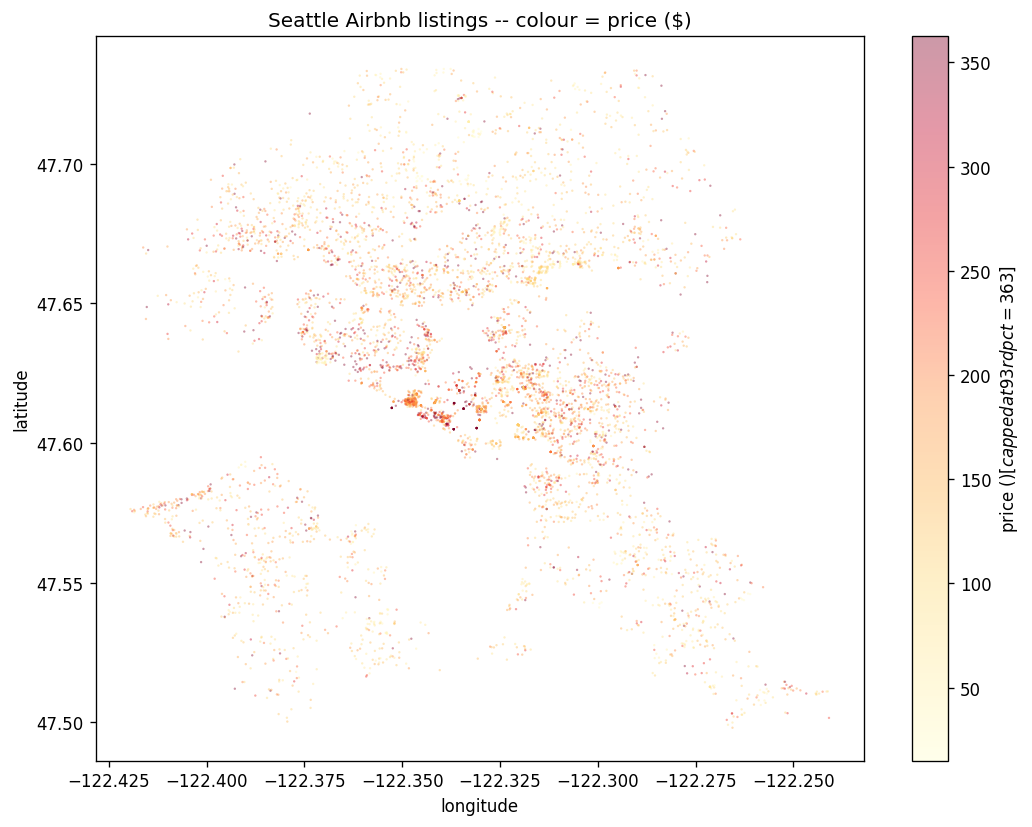

In [36]:
geo = df[["latitude", "longitude", "price"]].dropna()
# Cap at 93rd pct so residential color variation is visible
# (Hotel room prices ~$40k would wash out all residential variation at 99th pct)
price_cap = geo["price"].quantile(0.93)
price_display = geo["price"].clip(upper=price_cap)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    geo["longitude"], geo["latitude"],
    c=price_display, cmap="YlOrRd",
    s=2, alpha=0.4, linewidths=0,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(f"price ($)  [capped at 93rd pct = ${price_cap:.0f}]")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Seattle Airbnb listings -- colour = price ($)")
plt.tight_layout()
plt.show()

## Price by bedrooms

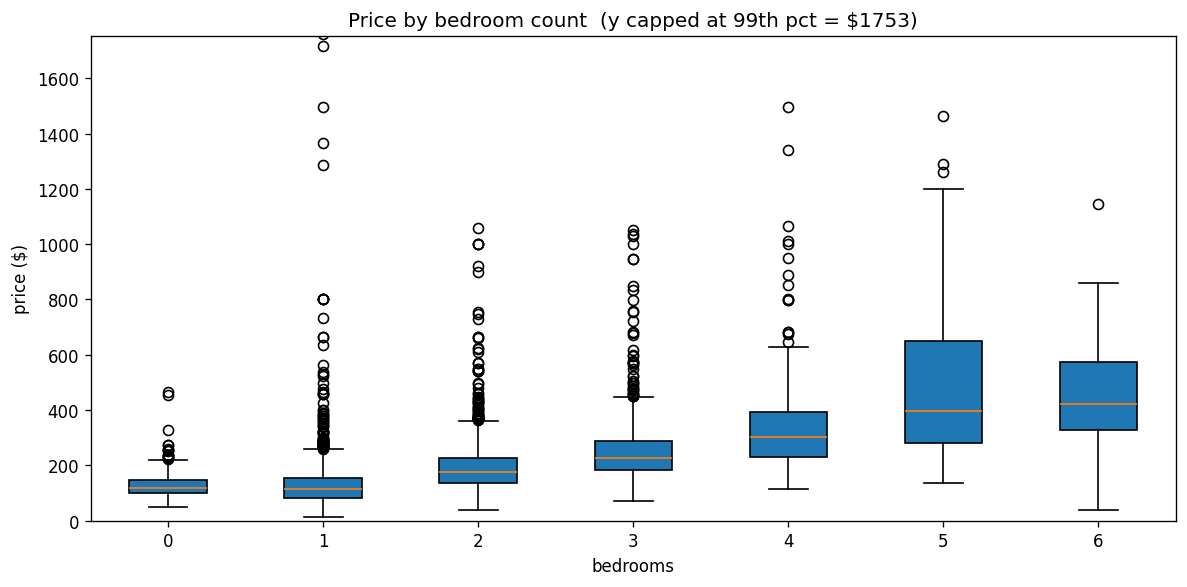

In [37]:
if "bedrooms" in df.columns:
    cap = df["price"].quantile(0.99)
    top_counts = df["bedrooms"].value_counts()
    valid_br = top_counts[top_counts >= 30].index.sort_values()
    br_data = [
        df.loc[df["bedrooms"] == br, "price"].dropna().values
        for br in valid_br
    ]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(br_data, tick_labels=[int(b) for b in valid_br], patch_artist=True)
    ax.set_ylim(0, cap)
    ax.set_xlabel("bedrooms")
    ax.set_ylabel("price ($)")
    ax.set_title(f"Price by bedroom count  (y capped at 99th pct = ${cap:.0f})")
    plt.tight_layout()
    plt.show()
else:
    print("bedrooms: column not found")

## Host and booking attributes

In [38]:
# Superhost price premium
if "host_is_superhost" in df.columns:
    grp = (
        df.groupby("host_is_superhost")["price"]
        .agg(count="count", mean="mean", median="median")
        .rename(index={"t": "superhost", "f": "not superhost"})
    )
    print("Price by superhost status:")
    print(grp.round(2).to_string())
else:
    print("host_is_superhost: column not found")

Price by superhost status:


                   count     mean  median
host_is_superhost                        
not superhost       2635  1093.92   143.0
superhost           3277   181.13   150.0


In [39]:
# Instant bookable price comparison
if "instant_bookable" in df.columns:
    grp = (
        df.groupby("instant_bookable")["price"]
        .agg(count="count", mean="mean", median="median")
        .rename(index={"t": "instant bookable", "f": "not instant bookable"})
    )
    print("Price by instant bookable:")
    print(grp.round(2).to_string())
else:
    print("instant_bookable: column not found")

Price by instant bookable:
                      count     mean  median
instant_bookable                            
not instant bookable   4189   180.50   138.0
instant bookable       2032  1378.22   166.0


### Host listing count vs price

In [40]:
if "calculated_host_listings_count" in df.columns:
    def _host_bucket(x):
        if x == 1:   return "1 (solo)"
        elif x <= 5: return "2-5 (small)"
        else:        return "6+ (professional)"

    _buckets = df["calculated_host_listings_count"].apply(
        lambda x: _host_bucket(x) if pd.notna(x) else None
    )
    order = ["1 (solo)", "2-5 (small)", "6+ (professional)"]
    grp = (
        df.assign(_bucket=_buckets)
        .groupby("_bucket")["price"]
        .agg(count="count", mean="mean", median="median")
        .reindex(order)
    )
    print("Price by host listing count bucket:")
    print(grp.round(1).to_string())
else:
    print("calculated_host_listings_count: column not found")

Price by host listing count bucket:
                   count    mean  median
_bucket                                 
1 (solo)            2351   221.6   146.0
2-5 (small)         1616   185.8   138.0
6+ (professional)   2254  1213.6   156.0


### License vs price

In [41]:
if "license" in df.columns:
    _has_lic = df["license"].notna()
    grp = (
        df.assign(_has_license=_has_lic)
        .groupby("_has_license")["price"]
        .agg(count="count", mean="mean", median="median")
        .rename(index={True: "has license", False: "no license"})
    )
    print("Price by license presence:")
    print(grp.round(1).to_string())
    print()
    print("Top license values (non-null):")
    print(df["license"].value_counts().head(8).to_string())
else:
    print("license: column not found")

Price by license presence:
              count   mean  median
_has_license                      
no license     1052  167.3   137.0
has license    5169  654.0   151.0

Top license values (non-null):
license
Exempt                334
STR-OPLI-24-000011     66
STR-OPLI-19-002641     37
str-opli-24-001459     35
STR-OPLI-19-002570     30
STR-OPLI-20-000157     25
STR-OPLI-25-003052     21
STR-OPLI-19-003321     17


## Minimum nights — identifying long-stay outliers

In [42]:
if "minimum_nights" in df.columns:
    mn = df["minimum_nights"]
    bins = [0, 1, 2, 7, 30, 90, mn.max() + 1]
    labels = ["1", "2", "3-7", "8-30", "31-90", "91+"]
    mn_cut = pd.cut(mn, bins=bins, labels=labels, right=True)
    vc = mn_cut.value_counts().sort_index()
    pct = (vc / len(df) * 100).round(1)
    summary = pd.DataFrame({"count": vc, "pct": pct})
    print("minimum_nights distribution:")
    print(summary.to_string())
    print()
    long_stay = (mn > 30).sum()
    print(f"Listings with min_nights > 30: {long_stay} ({long_stay/len(df)*100:.1f}%) "
          f"— consider excluding from nightly price modelling")
else:
    print("minimum_nights: column not found")

minimum_nights distribution:
                count   pct
minimum_nights             
1                1894  27.1
2                2033  29.1
3-7              1041  14.9
8-30             1604  22.9
31-90             388   5.5
91+                36   0.5

Listings with min_nights > 30: 424 (6.1%) — consider excluding from nightly price modelling


## Review sub-scores

In [43]:
REV_COLS = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]
rev_present = [c for c in REV_COLS if c in df.columns]
print(df[rev_present].describe().round(3).to_string())

       review_scores_rating  review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  review_scores_communication  review_scores_location  review_scores_value
count              6109.000                6109.000                   6109.000               6109.000                     6109.000                6109.000             6109.000
mean                  4.809                   4.838                      4.816                  4.879                        4.883                   4.834                4.718
std                   0.338                   0.301                      0.335                  0.255                        0.291                   0.263                0.357
min                   1.000                   1.000                      1.000                  1.000                        1.000                   1.000                1.000
25%                   4.780                   4.820                      4.780                  4.870                   

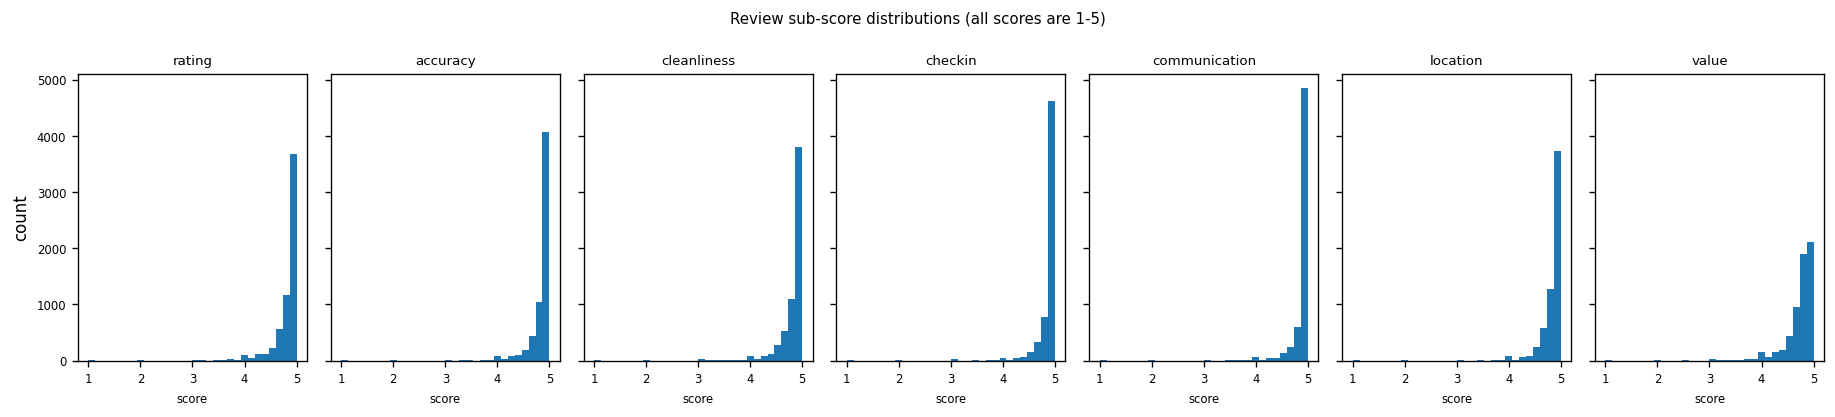

In [44]:
rev_present = [c for c in REV_COLS if c in df.columns]
if rev_present:
    fig, axes = plt.subplots(1, len(rev_present),
                             figsize=(len(rev_present) * 2.2, 3.5),
                             sharey=True)
    for ax, col in zip(axes, rev_present):
        data = df[col].dropna()
        ax.hist(data, bins=30, edgecolor="none")
        short = col.replace("review_scores_", "")
        ax.set_title(short, fontsize=8)
        ax.set_xlabel("score", fontsize=7)
        ax.tick_params(labelsize=7)
    axes[0].set_ylabel("count")
    fig.suptitle("Review sub-score distributions (all scores are 1-5)",
                 fontsize=9)
    plt.tight_layout()
    plt.show()

## Feature completeness for modelling

In [45]:
MODEL_FEATURES = [
    # target
    "price",
    # size / capacity
    "accommodates", "bedrooms", "bathrooms", "bathrooms_text", "beds",
    # listing type
    "room_type", "property_type",
    # location
    "neighbourhood_cleansed", "latitude", "longitude",
    # stay rules
    "minimum_nights",
    # host
    "host_is_superhost", "host_response_time", "host_response_rate",
    "host_acceptance_rate", "host_identity_verified",
    # reviews
    "number_of_reviews", "review_scores_rating", "reviews_per_month",
    # booking
    "instant_bookable", "availability_365",
    # amenities
    "amenities",
]

rows = []
for col in MODEL_FEATURES:
    if col not in df.columns:
        rows.append({"feature": col, "present": False, "pct_complete": 0.0})
    else:
        pct = (df[col].notna().mean() * 100)
        rows.append({"feature": col, "present": True, "pct_complete": round(pct, 1)})

completeness = pd.DataFrame(rows).sort_values("pct_complete", ascending=False)
print(completeness.to_string(index=False))

               feature  present  pct_complete
        minimum_nights     True         100.0
neighbourhood_cleansed     True         100.0
      availability_365     True         100.0
      instant_bookable     True         100.0
     number_of_reviews     True         100.0
          accommodates     True         100.0
             longitude     True         100.0
              latitude     True         100.0
             amenities     True         100.0
         property_type     True         100.0
             room_type     True         100.0
        bathrooms_text     True          99.8
              bedrooms     True          97.8
     host_is_superhost     True          95.2
host_identity_verified     True          95.0
             bathrooms     True          89.9
                  beds     True          89.8
                 price     True          88.9
  host_acceptance_rate     True          87.4
  review_scores_rating     True          87.3
     reviews_per_month     True   

## Modeling-eligible dataset size

Not all raw listings are usable for training a nightly price model. This section applies the two known filters in sequence and reports the final count — that filtered set is what the shared `get_train_test_split` call should operate on.


In [46]:
df_model = df.copy()
print(f"Starting rows: {len(df_model)}")

Starting rows: 6996


In [47]:
before = len(df_model)
df_model = df_model.dropna(subset=["price"])
dropped = before - len(df_model)
print(f"After dropping NaN price:          {len(df_model):>6} rows  ({dropped} dropped)")

After dropping NaN price:            6221 rows  (775 dropped)


In [48]:
before = len(df_model)
df_model = df_model[df_model["minimum_nights"] <= 30]
dropped = before - len(df_model)
print(f"After dropping minimum_nights > 30: {len(df_model):>6} rows  ({dropped} dropped)")

After dropping minimum_nights > 30:   5876 rows  (345 dropped)


In [49]:
# len(df) gives the raw row count without hardcoding a city-specific number
total = len(df)
final = len(df_model)
print(f"\nModeling-eligible rows: {final} / {total}  ({final/total*100:.1f}% of raw data)")


Modeling-eligible rows: 5876 / 6996  (84.0% of raw data)


> **Note:** The two filters above show notebook-level eligibility checks. The full `build_features` pipeline applies one more row drop: rows with an incomplete host-profile cluster (~35 rows). Hotel rooms are **kept** and flagged with `is_hotel_room`. **Final modeling set after the complete pipeline: 5,841 rows.** The shared train/test split is loaded from `data/raw/train_ids.npy` / `test_ids.npy` — never re-split.

> **Split note:** The fixed train/test split is owned by `common.py` (Person B). Load it with `common.load_split()` or directly via `np.load("data/raw/train_ids.npy")` / `np.load("data/raw/test_ids.npy")`. The split covers the 6,158 rows that survive Person B's filtering (non-null price, ≤ 99th-pct cap): 4,926 train / 1,232 test. Person A's tabular pipeline retains ~5,841 rows (drops min_nights > 30 and incomplete host profiles; Hotel rooms are kept with `is_hotel_room` flag). Use `df_feat["id"].isin(train_ids)` to align with the shared split — gives 4,620 train / 1,160 test rows.

## Notes / observations

*(Seattle Inside Airbnb snapshot, September 2025 — 6,996 listings, 79 columns.)*

---

### Dataset overview
- **6,996 listings, 79 columns.**
- `calendar_updated` is 100% empty — drop unconditionally.
- **Modeling-eligible set: 5,876 rows (84.0%)** after removing NaN-price rows (−775) and long-stay listings with minimum_nights > 30 (−345). After the full pipeline's host-profile filter (−35 rows) the final set is **5,841 rows** — Hotel rooms are kept and flagged with `is_hotel_room`.

---

### Target variable — price
- **Min $15, median $149, mean $571, max $50,039.** Strongly right-skewed — log-transform before regression. Target is `log_price = log(price)` from `common.load_target()` (Person B). Exponentiate predictions back to dollars for evaluation. Note: this is `log`, not `log1p` — the difference is negligible for prices ≥ $15 but must be consistent across the team.
- **No prices below $10** — the $10 floor in `features.py` is inert for Seattle (drops 0 rows; min price is $15).
- **Hotel room listings inflate every mean.** The 51 Hotel room rows have a mean of $43,990 and median of $40,100 — block-rate / convention pricing, not residential nightly STR. They are 0.7% of data but dominate any arithmetic mean. Flagged with `is_hotel_room` by `build_features` (step 6) and kept in the dataset so the model can learn the price discontinuity.
- Excluding Hotel rooms — Entire home/apt: mean $260, median $161; Private room: mean $103, median $76; Shared room: mean $31, median $23.
- 85 listings > $1,000 (1.4% of priced rows); 58 > $5,000 (0.9%).

---

### Neighbourhood structure
- **`neighbourhood_cleansed`:** Seattle names — Capitol Hill, Belltown, Queen Anne, Ballard, South Lake Union, Phinney Ridge, etc.
- **`neighbourhood_group_cleansed`:** 17 districts. Largest: Other neighborhoods (1,371), Downtown (899), Central Area (637), Capitol Hill (585), Queen Anne (576), West Seattle (503), Ballard (417).
- Neighbourhood mean prices are distorted by Hotel rooms concentrated downtown. Use **median**, not mean, when comparing neighbourhoods. Typical residential-area medians: $140–$250.

---

### Room and property types
- **Entire home/apt: 82.1% (5,745 rows).** Private room: 16.8% (1,175). Hotel room: 0.7% (51). Shared room: 0.4% (25).
- Top property types: Entire home (1,857), Entire rental unit (1,667), Private room in home (692), Entire townhouse (566), Entire condo (538), Entire guest suite (537).
- High property-type cardinality — group the long tail into "Other" before encoding (top-8 by train frequency, handled in `build_features` step 19).

---

### Missing values
| Column | Missing | Action |
|---|---|---|
| `bathrooms` | 10.1% (708 rows) | Parse `bathrooms_text` — covers all 708 missing rows exactly |
| `bedrooms` | 2.2% (151 rows) | Train-median imputation; add `bedrooms_missing` flag |
| review scores (7 cols) | 12.7% each | All missing together = no reviews yet; add `has_reviews` flag |
| `host_response_rate/time` | 15.3% | Sentinel/unknown imputation (−1 for rates, 'unknown' for time) |
| `price` (target) | 11.1% (775 rows) | Drop before training |
| `license` | 17.3% | Encode as binary `has_license` |

---

### Amenities
- Mean **43.2 amenities per listing** (range 1–92).
- Top amenities: Smoke alarm (98.8%), Carbon monoxide alarm (94.5%), Hot water (91.8%), Kitchen (89.0%), Wifi (85.1%).
- Encode as: `amenities_count` (numeric) + binary flags for targeted amenities in `features.py`.

---

### License
- **82.7% of listings have a license** (5,785 / 6,996). Format: `STR-OPLI-YY-XXXXXX`. "Exempt" (334 listings) = exemption-qualifying properties.
- Encode as binary `has_license`.

---

### Minimum nights
- **6.1% of listings (424) have minimum_nights > 30** — excluded from nightly price modeling.

---

### Host and booking attributes
- **Superhost** — median $150 vs $143 (not superhost). Use medians; means are Hotel-room-inflated.
- **Instant bookable** — median $166 (instant) vs $138 (not instant).
- **Host listing count** — solo: median $146; small (2–5): $138; professional (6+): $156.

---

### Review scores
- **87.3% of listings have reviews** (6,109 / 6,996). Mean rating: 4.809.
- Retain `review_scores_rating`, `review_scores_value`, `review_scores_location`. Drop other 4 sub-scores (collinear).

---

### Pipeline decisions (implemented in `build_features`)
1. **Hotel room flag:** `is_hotel_room` binary column (step 6) — kept in dataset, not dropped.
2. **Outlier clipping:** train-set 99.9th percentile for maximum_nights, bedrooms, bathrooms, revenue, reviews_per_month (step 5).
3. **min_nights > 30 drop:** 424 rows removed (step 1).
4. **$10 price floor:** inert for Seattle but kept as a safety guard (step 3).

## Part 2 — Train set: before preprocessing

Same price-cleaned listings as Part 1, but restricted to the **4,926 training IDs** from `common.py`.
No pipeline transformations have been applied yet — this shows what goes *into* `build_features`.
Use this section to verify distributions and missing-value rates on the data the model will actually be trained on.

Train listings before preprocessing : 4,926 rows
Test  listings before preprocessing : 1,232 rows
Not in either split (outside common.py split): 838

Price (train) — n=4,926  min=$15  median=$147  mean=$177  max=$1717


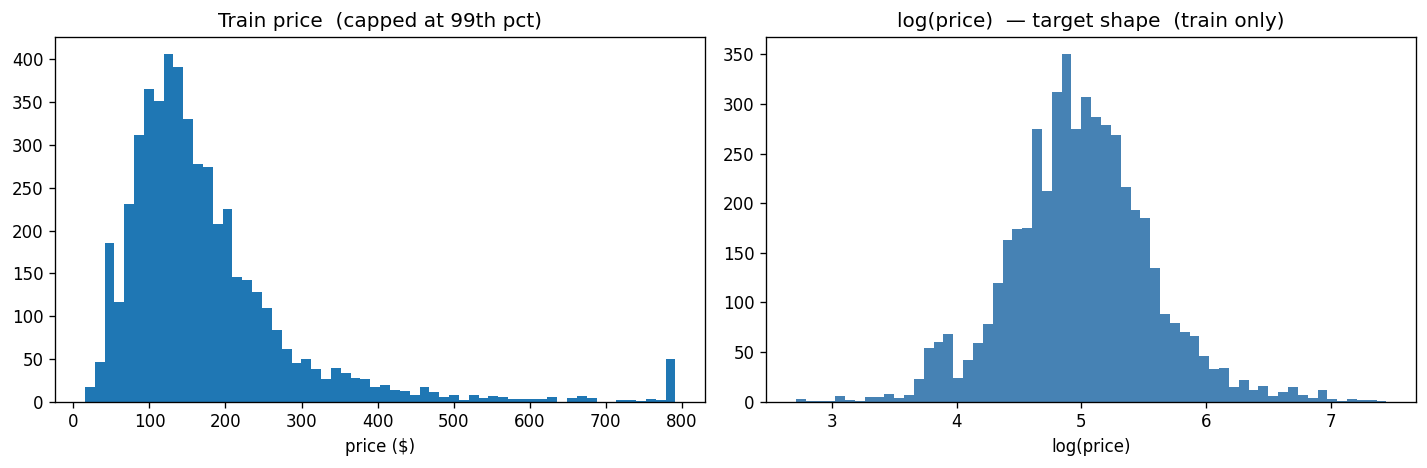


Columns with missing values in train (38 cols):
calendar_updated               100.0
neighbourhood                   40.5
neighborhood_overview           40.5
host_about                      33.5
host_location                   19.2
license                         17.2
host_response_rate              12.8
host_response_time              12.8
host_acceptance_rate            11.7
reviews_per_month               11.6
review_scores_communication     11.6
review_scores_location          11.6
review_scores_checkin           11.6
review_scores_value             11.6
review_scores_cleanliness       11.6
review_scores_accuracy          11.6
review_scores_rating            11.6
last_review                     11.6
first_review                    11.6
host_neighbourhood               9.0
host_is_superhost                5.0
host_verifications               4.9
host_has_profile_pic             4.9
host_identity_verified           4.9
host_total_listings_count        4.9
host_picture_url          

In [50]:
import numpy as np

_train_ids = np.load("../data/raw/train_ids.npy")
_test_ids  = np.load("../data/raw/test_ids.npy")

# Filter price-cleaned df to train listings only (before any pipeline steps)
df_tr_raw = df[df["id"].isin(_train_ids)].reset_index(drop=True)

print(f"Train listings before preprocessing : {len(df_tr_raw):,} rows")
print(f"Test  listings before preprocessing : {(df['id'].isin(_test_ids)).sum():,} rows")
print(f"Not in either split (outside common.py split): "
      f"{(~df['id'].isin(_train_ids) & ~df['id'].isin(_test_ids)).sum():,}")

# Price distribution in train set
price_tr = df_tr_raw["price"].dropna()
print(f"\nPrice (train) — n={len(price_tr):,}  "
      f"min=${price_tr.min():.0f}  median=${price_tr.median():.0f}  "
      f"mean=${price_tr.mean():.0f}  max=${price_tr.max():.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(price_tr.clip(upper=price_tr.quantile(0.99)), bins=60, edgecolor="none")
ax1.set_title("Train price  (capped at 99th pct)")
ax1.set_xlabel("price ($)")
ax2.hist(np.log(price_tr), bins=60, edgecolor="none", color="steelblue")
ax2.set_title("log(price)  — target shape  (train only)")
ax2.set_xlabel("log(price)")
plt.tight_layout()
plt.show()

# Missing values in train set before pipeline
missing_tr = (df_tr_raw.isnull().mean() * 100).sort_values(ascending=False)
missing_tr = missing_tr[missing_tr > 0]
print(f"\nColumns with missing values in train ({len(missing_tr)} cols):")
print(missing_tr.round(1).to_string())

# Key numeric stats (train, before preprocessing)
num_cols = ["accommodates", "bedrooms", "bathrooms",
            "minimum_nights", "number_of_reviews", "review_scores_rating"]
print("\nNumeric feature stats (train, before preprocessing):")
print(df_tr_raw[[c for c in num_cols if c in df_tr_raw.columns]].describe().round(2).to_string())

# Categorical distributions in train
for col in ("room_type", "property_type"):
    if col in df_tr_raw.columns:
        vc = df_tr_raw[col].value_counts()
        print(f"\n{col} (train, before preprocessing):")
        print(vc.head(10).to_string())

## Part 3 — Train set: after preprocessing

Verify the `build_features` pipeline output on train rows.
All reported stats (frequencies, medians, distributions) come from the training split only.

In [51]:
import numpy as np

train_ids = np.load("../data/raw/train_ids.npy")
test_ids  = np.load("../data/raw/test_ids.npy")

train_feat = pd.read_csv("../data/processed/tabular_train.csv")
test_feat  = pd.read_csv("../data/processed/tabular_test.csv")

print(f"Loaded from processed CSVs (run save_features.py to regenerate if pipeline changes):")
print(f"  tabular_train.csv : {len(train_feat):,} rows × {train_feat.shape[1]} columns")
print(f"  tabular_test.csv  : {len(test_feat):,} rows × {test_feat.shape[1]} columns")
print(f"NaN total (train)  : {train_feat.isna().sum().sum()}")
print("\nAll columns:")
print(train_feat.columns.tolist())

Loaded from processed CSVs (run save_features.py to regenerate if pipeline changes):
  tabular_train.csv : 4,926 rows × 50 columns
  tabular_test.csv  : 1,232 rows × 50 columns
NaN total (train)  : 0

All columns:
['id', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'review_scores_rating', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_priva

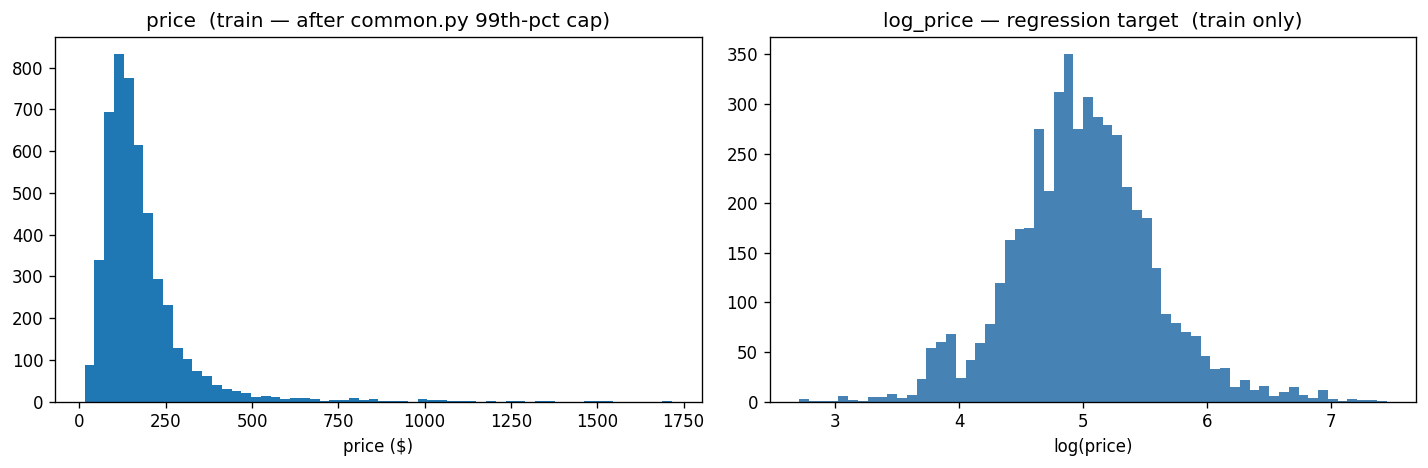

price     median: 147   mean: 177   max: 1717
log_price median: 4.99   std: 0.579


In [52]:
# Target lives in common.py's target.csv — log_price = log(price), NOT log1p.
# Load and slice to train rows only for stat reporting.
target      = pd.read_csv("../data/raw/target.csv")   # id, price, log_price
train_tgt   = target[target["id"].isin(train_ids)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(train_tgt["price"], bins=60, edgecolor="none")
ax1.set_title("price  (train — after common.py 99th-pct cap)")
ax1.set_xlabel("price ($)")

ax2.hist(train_tgt["log_price"], bins=60, edgecolor="none", color="steelblue")
ax2.set_title("log_price — regression target  (train only)")
ax2.set_xlabel("log(price)")

plt.tight_layout()
plt.show()

print("price     median:", round(train_tgt["price"].median()),
      "  mean:", round(train_tgt["price"].mean()),
      "  max:", round(train_tgt["price"].max()))
print("log_price median:", round(train_tgt["log_price"].median(), 3),
      "  std:", round(train_tgt["log_price"].std(), 3))

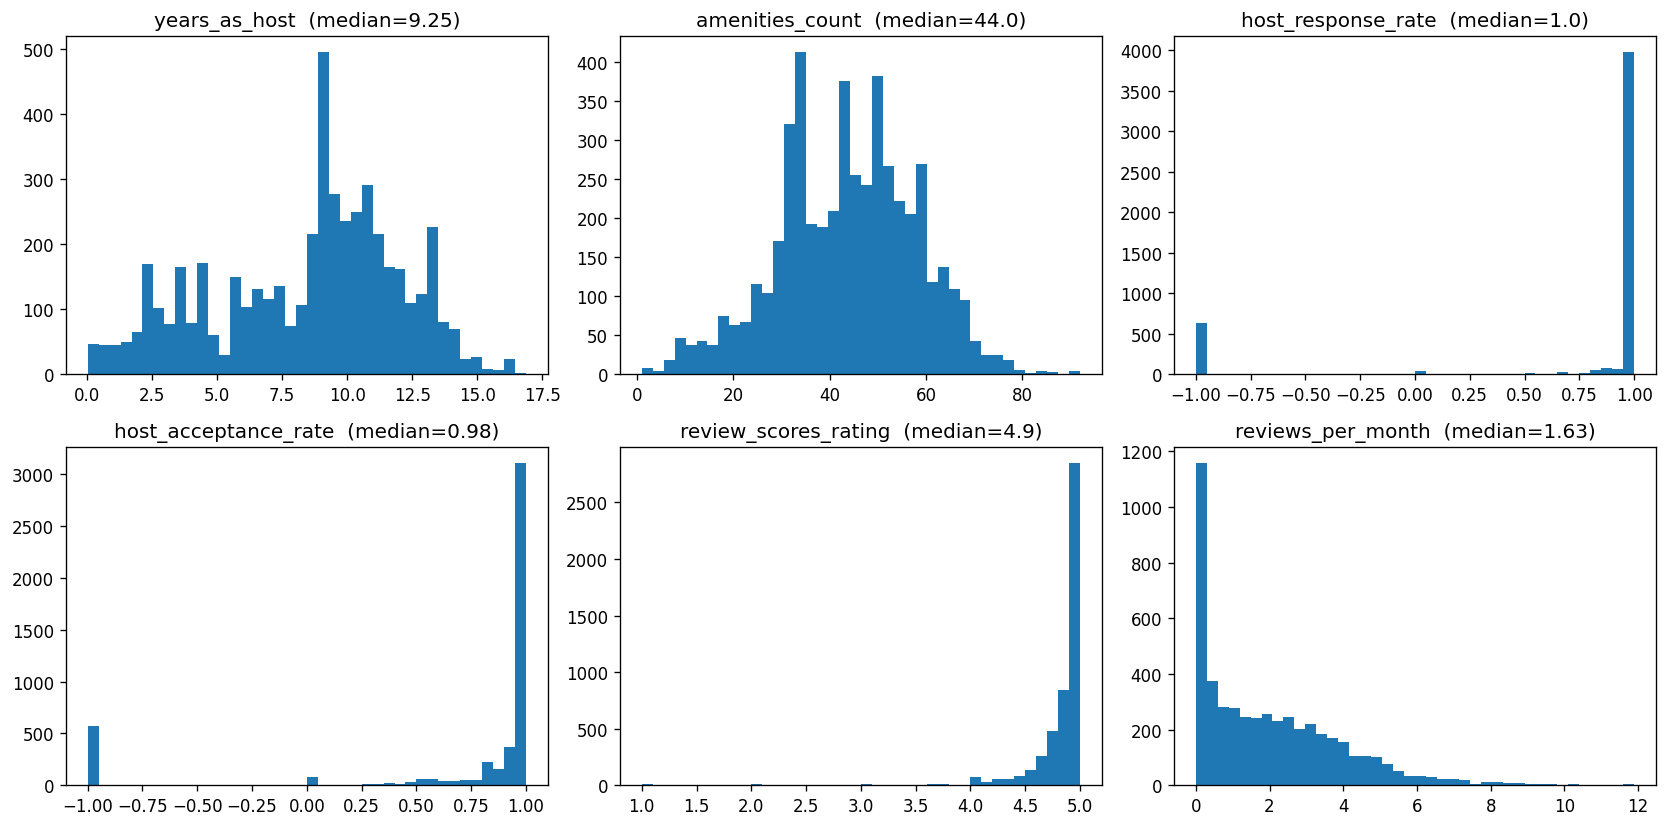

In [53]:
# Distributions of key engineered numeric features — train split only
eng_num = ["years_as_host", "amenities_count", "host_response_rate",
           "host_acceptance_rate", "review_scores_rating", "reviews_per_month"]
present = [c for c in eng_num if c in train_feat.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, present):
    data = train_feat[col]
    ax.hist(data, bins=40, edgecolor="none")
    ax.set_title(col + "  (median=" + str(round(data.median(), 2)) + ")")
for ax in axes.flat[len(present):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

In [54]:
# Binary flag features — frequencies from train split only (4,620 rows after tabular pipeline)
# Ideal range 5%–95% for useful variance.
flag_cols = sorted(
    [c for c in train_feat.columns
     if c.startswith("has_") or c in ("is_shared_bath", "is_hotel_room", "bedrooms_missing")],
    key=lambda c: train_feat[c].mean(), reverse=True
)
print("Feature                         % = 1   count  (train only)")
print("-" * 55)
for col in flag_cols:
    pct = train_feat[col].mean() * 100
    cnt = int(train_feat[col].sum())
    warn = "  <- low variance" if pct < 5 or pct > 95 else ""
    print(f"{col:<30}  {pct:5.1f}%  {cnt:>5}{warn}")

Feature                         % = 1   count  (train only)
-------------------------------------------------------
has_wifi                         99.2%   4887  <- low variance
has_kitchen                      94.5%   4654
has_parking                      90.6%   4463
has_reviews                      88.4%   4356
has_license                      82.8%   4081
has_dedicated_workspace          65.6%   3232
has_ac                           44.5%   2193
has_elevator                     15.8%    778
is_shared_bath                    9.2%    451
bedrooms_missing                  0.2%     10  <- low variance


In [55]:
# Categorical columns — cardinality and top-value frequency from train split only
# NOTE: neighbourhood_cleansed (87) and neighbourhood_group_cleansed (17) are
# hierarchically related — use ONE at training time (not both).
# Recommendation: neighbourhood_cleansed with target encoding for best signal;
#                 neighbourhood_group_cleansed with one-hot for a quick baseline.
cat_cols = train_feat.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns ({len(cat_cols)})  — frequencies from train split only:")
print("Column                               Unique  Top value")
print("-" * 75)
for col in cat_cols:
    n       = train_feat[col].nunique()
    top     = train_feat[col].value_counts().index[0]
    top_pct = train_feat[col].value_counts().iloc[0] / len(train_feat) * 100
    warn    = "  <- near-constant" if top_pct > 95 else ""
    print(f"{col:<35}  {n:>6}  {repr(str(top))} ({top_pct:.0f}%){warn}")

Categorical columns (11)  — frequencies from train split only:
Column                               Unique  Top value
---------------------------------------------------------------------------
host_response_time                        5  'within an hour' (77%)
host_is_superhost                         2  't' (53%)
host_verifications                        6  "['email', 'phone']" (76%)
host_has_profile_pic                      2  't' (94%)
host_identity_verified                    2  't' (85%)
neighbourhood_cleansed                   88  'Broadway' (6%)
neighbourhood_group_cleansed             17  'Other neighborhoods' (20%)
property_type                             9  'Entire home' (26%)
room_type                                 3  'Entire home/apt' (83%)
instant_bookable                          2  'f' (68%)
host_listing_bucket                       3  '1 (solo)' (37%)


/var/folders/vw/k61bmxfn7gl5lp3xx6606r480000gn/T/ipykernel_4808/1131221171.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_feat.select_dtypes(include="object").columns.tolist()
